# Задание 1. Анализ и подготовка временного ряда

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/gaming_seasonal.csv', parse_dates=['time'], index_col='time')

print("Наблюдений:", len(df))
print(f"Период: {df.index[0]} — {df.index[-1]}")
print("Столбец:", list(df.columns))

series = df['active_players'].copy()

print(f"Среднее: {series.mean():.2f}")
print(f"Мин: {series.min():.2f}")
print(f"Макс: {series.max():.2f}")
print(f"Станд.отклонение: {series.std():.2f}")
print(f"Пропуски: {series.isnull().sum()}")

Наблюдений: 200
Период: 2020-01-01 00:00:00 — 2020-07-18 00:00:00
Столбец: ['active_players']
Среднее: 50.46
Мин: 37.14
Макс: 64.26
Станд.отклонение: 7.39
Пропуски: 0


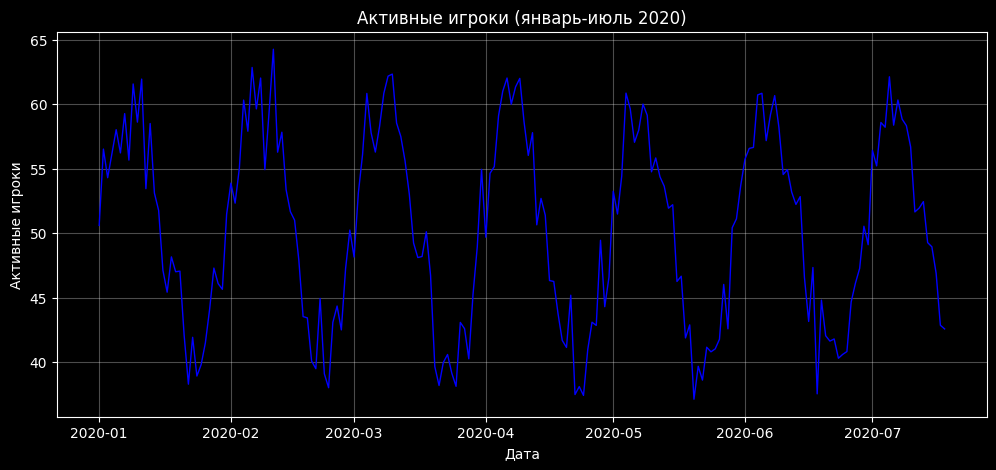

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, color='blue', linewidth=1)
plt.title('Активные игроки (январь-июль 2020)')
plt.xlabel('Дата')
plt.ylabel('Активные игроки')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
Q1 = series.quantile(0.25)
Q3 = series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = series[(series < lower_bound) | (series > upper_bound)]
print(f'Количество выбросов: {len(outliers)}')

Количество выбросов: 0


Тренд: явно выраженного тренда не наблюдается.

Сезонность: ряд имеет ежемесясячную цикличность с периодом около 30 дней. Пики активности приходятся на первые числа месяца, а спады — на вторую половину.

Выбросы: отсутствуют

In [6]:
result = adfuller(series.dropna())
print(f'ADF статистика: {result[0]:.4f}')
print(f'p-value: {result[1]:.6f}')
print(f'Критические значения: 1%: {result[4]["1%"]:.4f}, 5%: {result[4]["5%"]:.4f}, 10%: {result[4]["10%"]:.4f}')
print(f'Ряд стационарен' if result[1] < 0.05 else f'Ряд нестационарен')

ADF статистика: -8.2720
p-value: 0.000000
Критические значения: 1%: -3.4662, 5%: -2.8773, 10%: -2.5752
Ряд стационарен


По графику видно, что ряд колеблется вокруг среднего значения без явного тренда. ADF-тест даёт p-value ≈ 0.000 - это означает, что ряд является стационарным. И хотя преобразование для достижения стационарности не требуется, всё же применим дифференцирование и оценим его влияние.

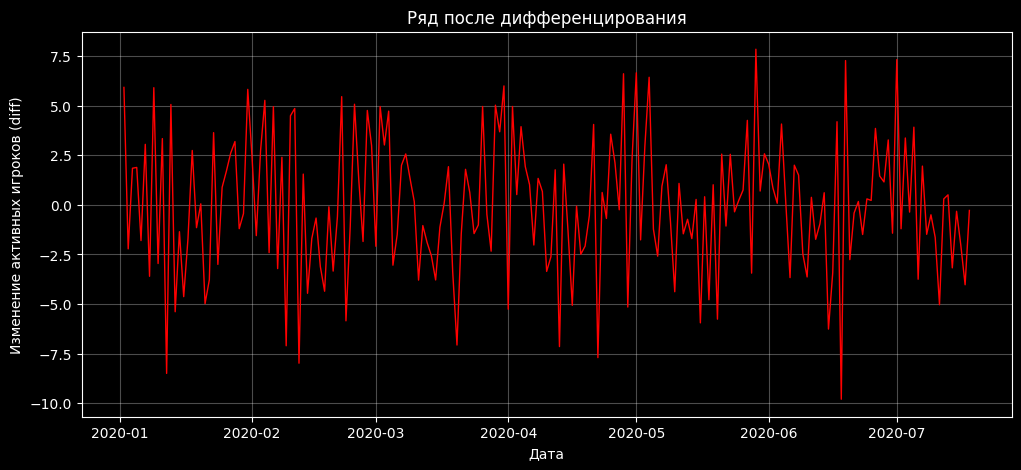

ADF статистика: -9.6702
p-value: 0.000000
Ряд стационарен


In [5]:
series_diff = series.diff().dropna()

plt.figure(figsize=(12, 5))
plt.plot(series_diff.index, series_diff.values, color='red', linewidth=1)
plt.title('Ряд после дифференцирования')
plt.xlabel('Дата')
plt.ylabel('Изменение активных игроков (diff)')
plt.grid(True, alpha=0.3)
plt.show()

result_diff = adfuller(series_diff)
print(f'ADF статистика: {result_diff[0]:.4f}')
print(f'p-value: {result_diff[1]:.6f}')
print(f'Ряд стационарен' if result_diff[1] < 0.05 else f'Ряд нестационарен')

Почему дифференцирование ухудшило ряд

Исходный ряд уже стационарен, поэтому дифференцирование оказалось избыточным. Это привело к таким проблемам:
- Потеря масштаба
- Усиление шума
- Потеря информации

# Задание 2. Базовая ARIMA-модель

Train: 170 дней (2020-01-01 — 2020-06-18)
Test: 30 дней (2020-06-19 — 2020-07-18)


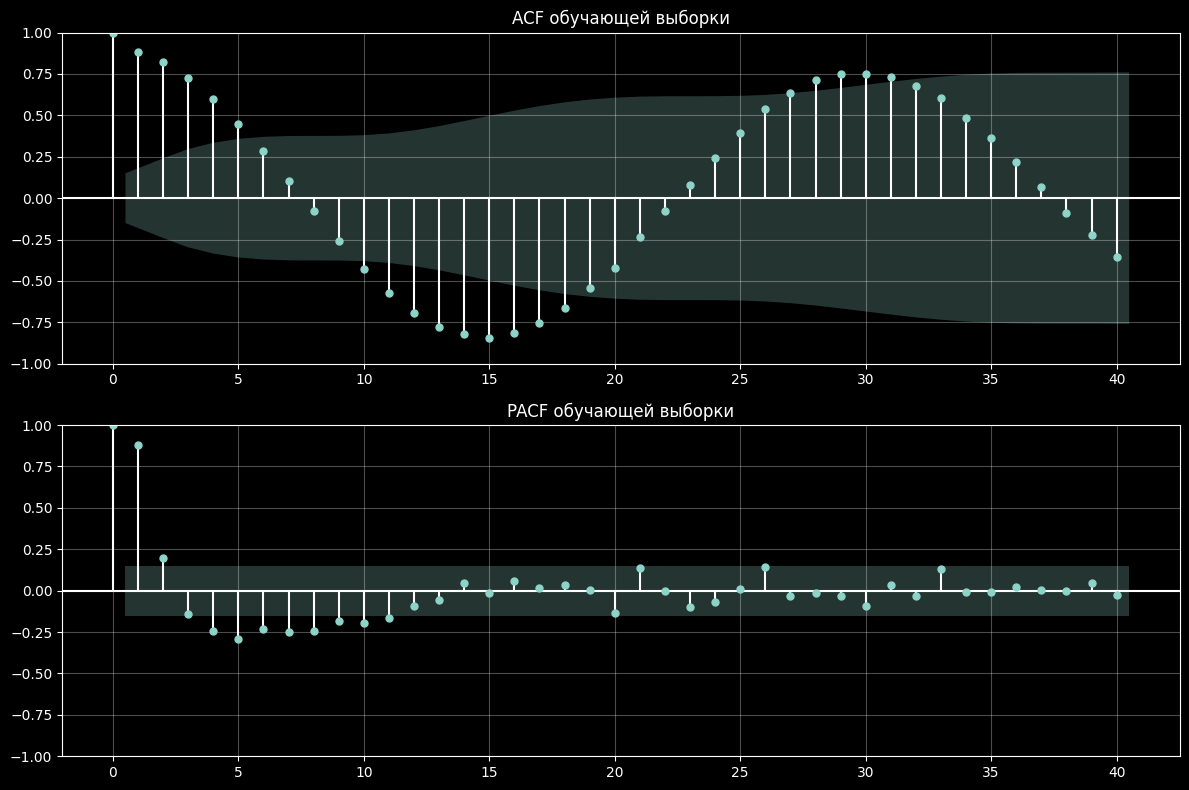

In [16]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Разбиваем на train/test (последние 30 дней на тест)
test_days = 30
train = series.iloc[:-test_days].copy()
test = series.iloc[-test_days:].copy()

print(f'Train: {len(train)} дней ({train.index[0].date()} — {train.index[-1].date()})')
print(f'Test: {len(test)} дней ({test.index[0].date()} — {test.index[-1].date()})')

# 1. Построение ACF и PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(train, lags=40, ax=ax1)
plot_pacf(train, lags=40, ax=ax2, method='ywm')
ax1.set_title('ACF обучающей выборки')
ax2.set_title('PACF обучающей выборки')
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Выбор параметров ARIMA

d = 0, т.к. ряд стационарен

p = 1, т.к. PACF резко обрывается после лага 1

q = 0, т.к. график ACF не обрывается, а плавно затухает

Получаем модель ARIMA(1, 0, 0)

                               SARIMAX Results                                
Dep. Variable:         active_players   No. Observations:                  170
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -450.960
Date:                Tue, 09 Jun 2026   AIC                            907.921
Time:                        19:05:54   BIC                            917.328
Sample:                    01-01-2020   HQIC                           911.738
                         - 06-18-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.9709      2.457     20.337      0.000      45.155      54.787
ar.L1          0.8916      0.038     23.159      0.000       0.816       0.967
sigma2        11.6840      1.397      8.363      0.0

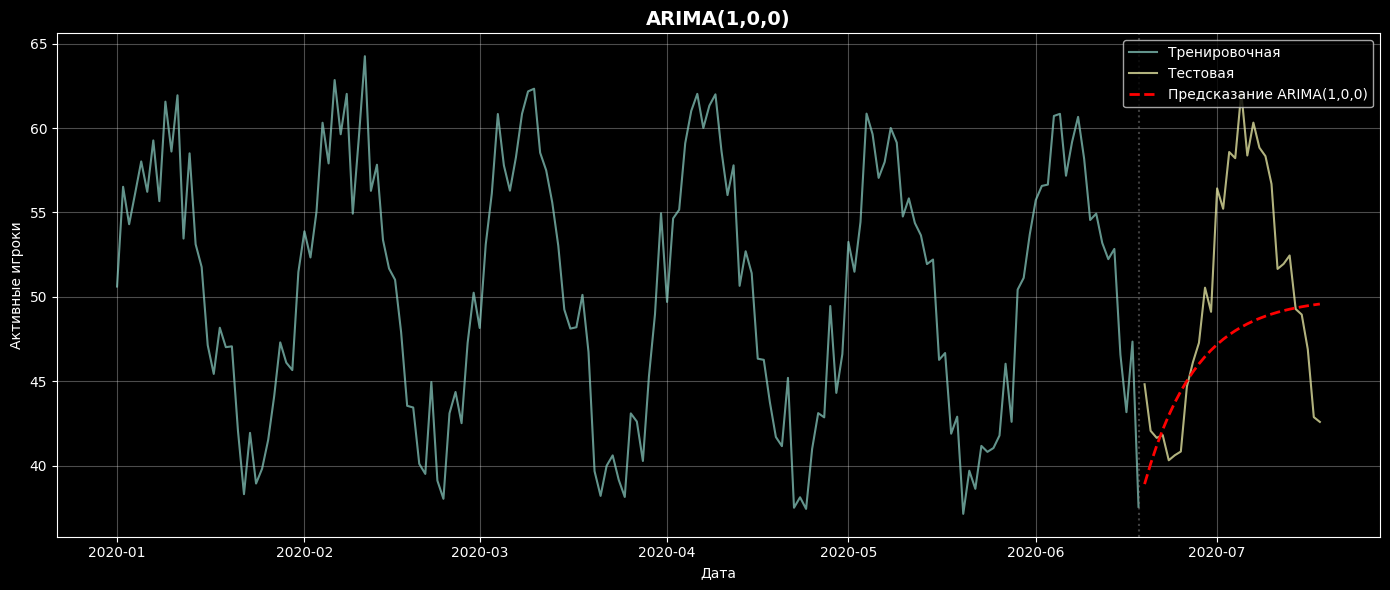

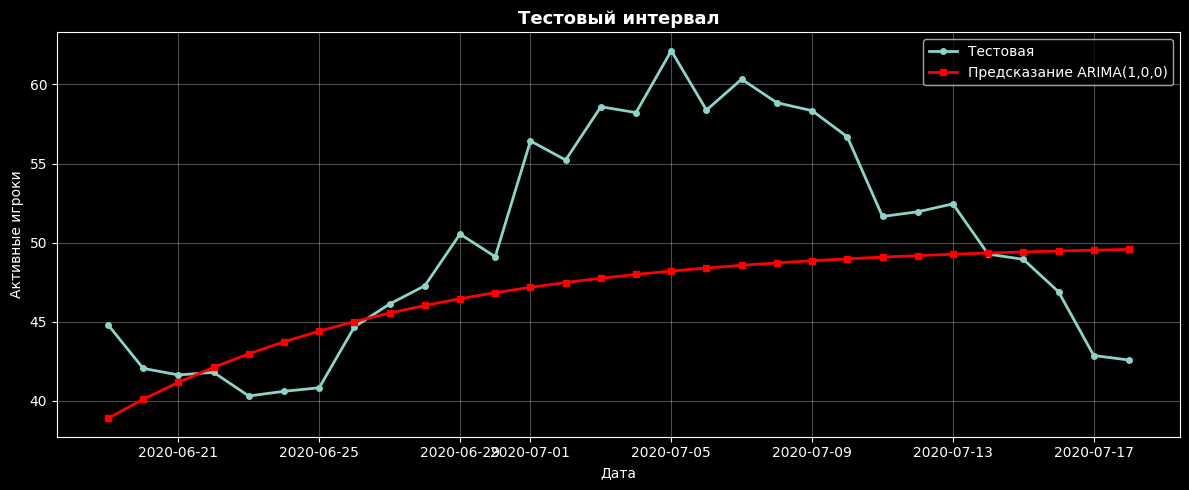

In [42]:
model = ARIMA(train, order=(1, 0, 0))
model_fit = model.fit()
print(model_fit.summary())

forecast = model_fit.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"\n=== Качество прогноза на тестовой выборке ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Тренировочная', alpha=0.7, linewidth=1.5)
ax.plot(test.index, test, label='Тестовая', alpha=0.7, linewidth=1.5)
ax.plot(test.index, forecast, label='Предсказание ARIMA(1,0,0)',
        color='red', linewidth=2, linestyle='--')
ax.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.5)
ax.set_title('ARIMA(1,0,0)', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Активные игроки')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test, label='Тестовая', marker='o', linewidth=2, markersize=4)
ax.plot(test.index, forecast, label='Предсказание ARIMA(1,0,0)', marker='s',
        color='red', linewidth=2, markersize=4)
ax.set_title('Тестовый интервал',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Активные игроки')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Задание 3. Диагностика модели

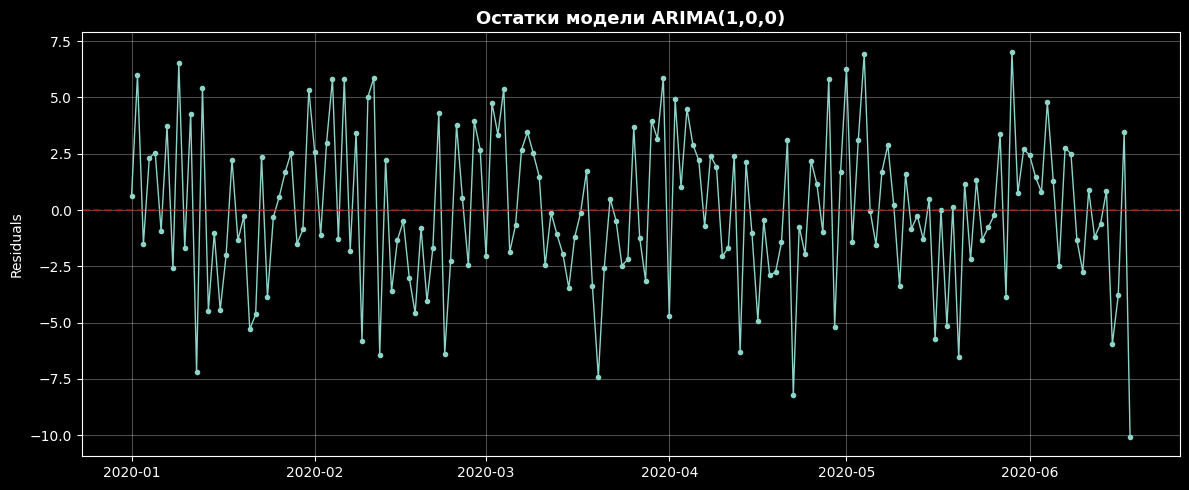

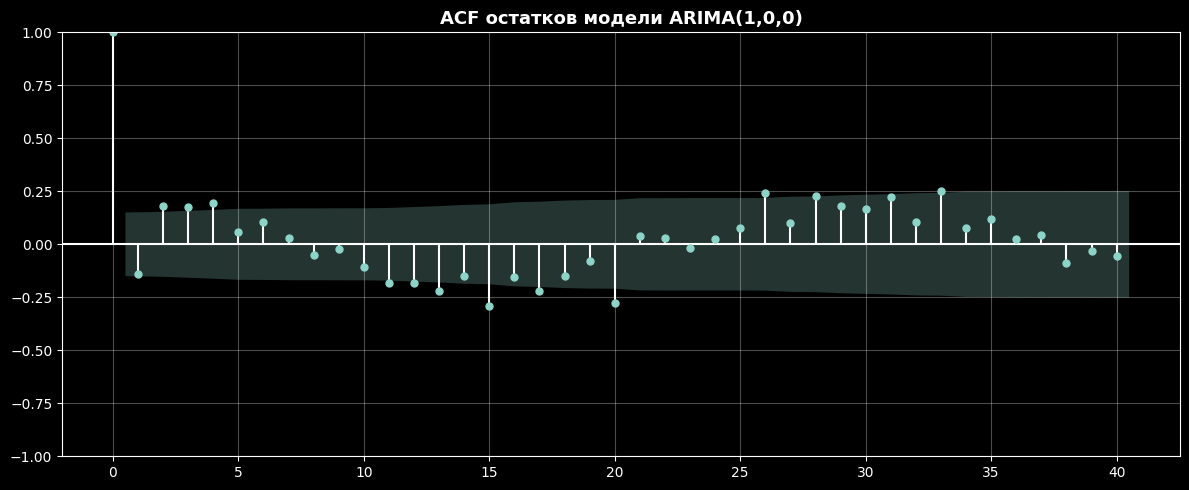


=== Тест Льюнга-Бокса ===
       lb_stat     lb_pvalue
10   26.537497  3.080727e-03
15   67.662828  1.161030e-08
20  101.779032  6.043305e-13


In [25]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_fit.resid

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(residuals.index, residuals, marker='o', markersize=3, linewidth=1)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Остатки модели ARIMA(1,0,0)', fontsize=13, fontweight='bold')
ax.set_ylabel('Residuals')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(residuals, lags=40, ax=ax)
ax.set_title('ACF остатков модели ARIMA(1,0,0)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 15, 20], return_df=True)
print("\n=== Тест Льюнга-Бокса ===")
print(lb_test)

Модель ARIMA(1,0,0) неадекватна, потому что:
- На графике остатков видна цикличность (30 дней)
- Тест Льюнга-Бокса показал наличие автокорреляции (p < 0.05)

Причина - модель не учла сезонность с периодом 30 дней, т.к. не предназначена для работы с сезонностью. Поэтому нет смысла пытаться улучшить модель ARIMA и стоит перейти к SARIMA, которая сезонность учитывает.

## Задание 4. Сезонная модель SARIMA

1. Проверить наличие сезонности (визуально и через декомпозицию).
2. Построить SARIMA-модель.
3. Сравнить с ARIMA по качеству прогноза.
4. Объяснить, в каких случаях SARIMA даёт преимущество. 

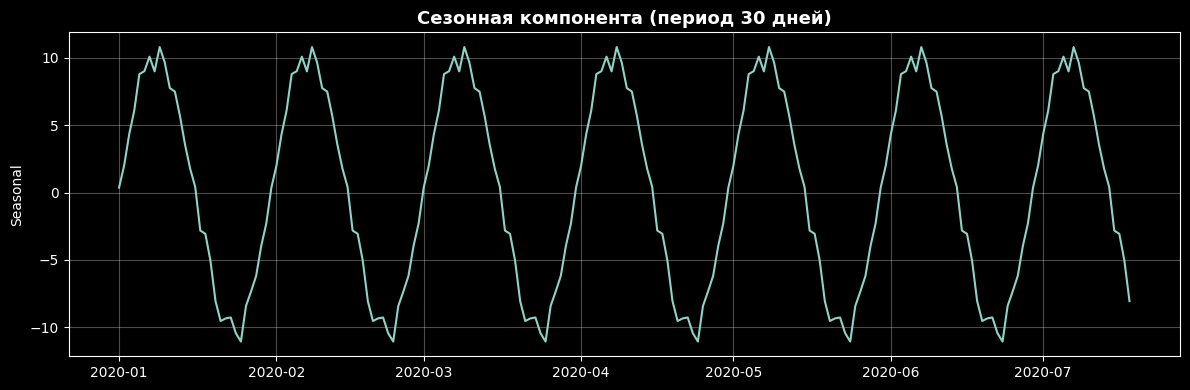

In [31]:
decomposition = seasonal_decompose(series, model='additive', period=30)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(decomposition.seasonal)
ax.set_title('Сезонная компонента (период 30 дней)', fontsize=13, fontweight='bold')
ax.set_ylabel('Seasonal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Сезонность подтвердилась через декомпозицию

Сравнение моделей
ARIMA(1,0,0): RMSE=6.5014, MAPE=9.59%
SARIMA(1,0,0)(1,0,0,30): RMSE=14.4717, MAPE=25.01%


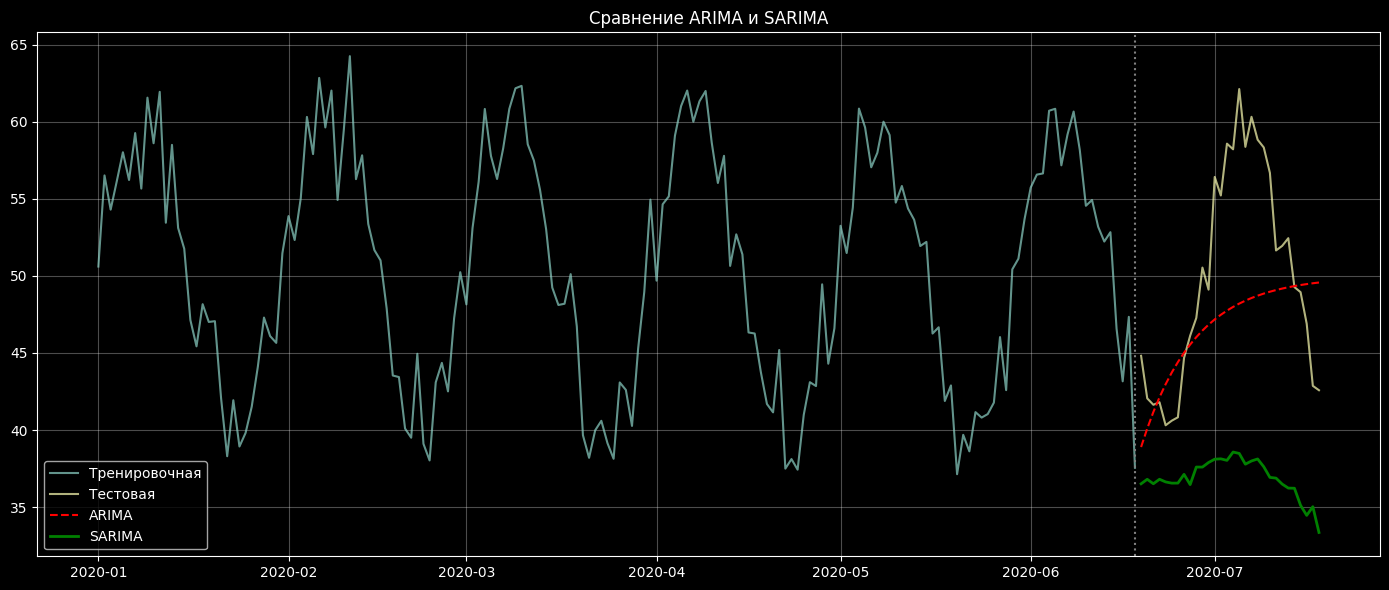

In [48]:
model_sarima = SARIMAX(train, order=(1, 0, 0), seasonal_order=(1, 0, 0, 30))
sarima_fit = model_sarima.fit(disp=False)
forecast_sarima = sarima_fit.forecast(steps=len(test))

rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mape_sarima = mean_absolute_percentage_error(test, forecast_sarima) * 100

print("Сравнение моделей")
print(f"ARIMA(1,0,0): RMSE={rmse:.4f}, MAPE={mape:.2f}%")
print(f"SARIMA(1,0,0)(1,0,0,30): RMSE={rmse_sarima:.4f}, MAPE={mape_sarima:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Тренировочная', alpha=0.7)
ax.plot(test.index, test, label='Тестовая', alpha=0.7)
ax.plot(test.index, forecast, label='ARIMA', color='red', linestyle='--')
ax.plot(test.index, forecast_sarima, label='SARIMA', color='green', linewidth=2)
ax.axvline(x=train.index[-1], color='gray', linestyle=':')
ax.set_title('Сравнение ARIMA и SARIMA'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

SARIMA стала хуже, чем простая ARIMA

Это произошло потому что модель пытается учесть сразу две вещи:
- что было вчера (p = 1)
- что было месяц назад (сезонность)

Изменим параметр p на 0, оставив только сезонность

Сравнение моделей
ARIMA(1,0,0): RMSE=6.5014, MAPE=9.59%
SARIMA(0,0,0)(1,0,0,30): RMSE=2.8062, MAPE=4.67%


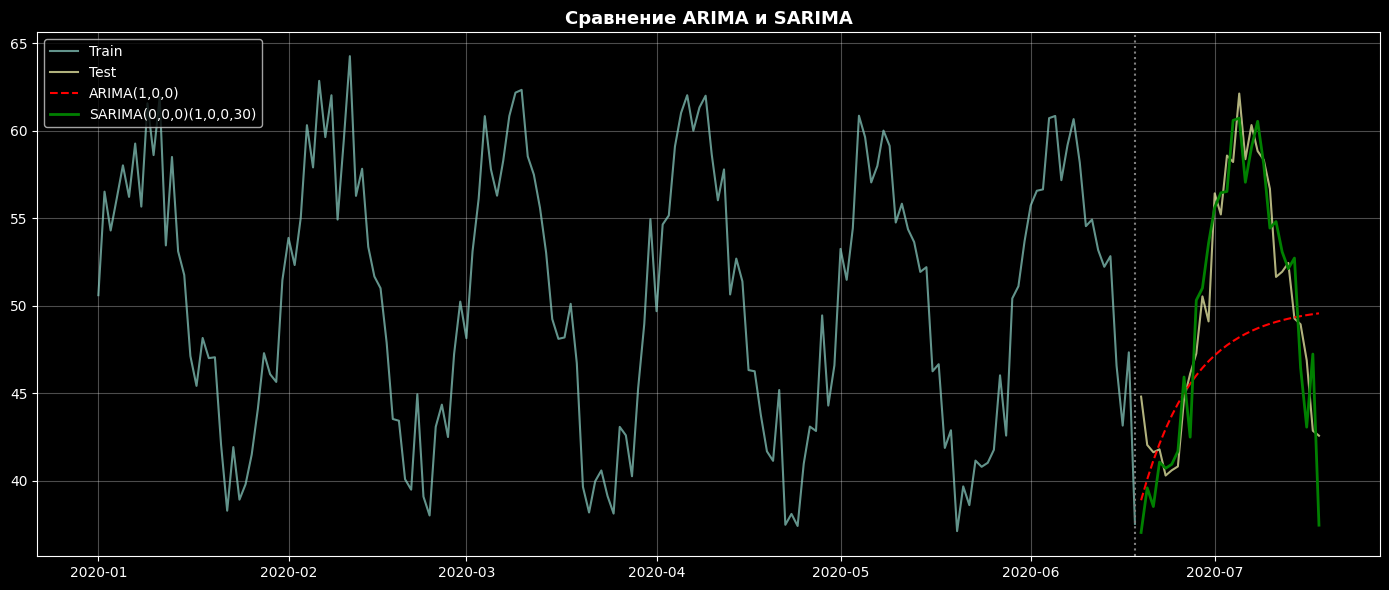

In [57]:
model_s2 = SARIMAX(train, order=(0, 0, 0), seasonal_order=(1, 0, 0, 30))
fit_s2 = model_s2.fit(disp=False)
forecast_s2 = fit_s2.forecast(steps=len(test))

rmse_s2 = np.sqrt(mean_squared_error(test, forecast_s2))
mape_s2 = mean_absolute_percentage_error(test, forecast_s2) * 100

print("Сравнение моделей")
print(f"ARIMA(1,0,0): RMSE={rmse:.4f}, MAPE={mape:.2f}%")
print(f"SARIMA(0,0,0)(1,0,0,30): RMSE={rmse_s2:.4f}, MAPE={mape_s2:.2f}%")

# Финальная визуализация
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Train', alpha=0.7)
ax.plot(test.index, test, label='Test', alpha=0.7)
ax.plot(test.index, forecast, label='ARIMA(1,0,0)', color='red', linestyle='--')
ax.plot(test.index, forecast_s2, label='SARIMA(0,0,0)(1,0,0,30)',
        color='green', linewidth=2)
ax.axvline(x=train.index[-1], color='gray', linestyle=':')
ax.set_title('Сравнение ARIMA и SARIMA', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SARIMA выигрывает у ARIMA, когда в данных есть сезонность — повторяющиеся паттерны с фиксированным периодом (сутки, неделя, месяц, год).

Типичные случаи:
- Продажи (пики перед праздниками)
- Энергопотребление (суточные и недельные циклы)
- Веб-трафик (активность днём и в будни)
- Погодные данные (годовые циклы)

Почему ARIMA не справляется: она учитывает только "вчера" и "позавчера", но не видит паттерны с периодом в месяц или год.

# Задание 5. SARIMAX и внешние факторы

### Обоснование выбора факторов

**dayofweek (день недели):** Активность игроков зависит от дня недели — в будни и выходные паттерны поведения различаются. Например, в выходные больше свободного времени, что может увеличивать активность.

**is_weekend (выходной):** Бинарный признак, выделяющий субботу и воскресенье. Выходные дни часто дают всплески активности в играх, так как у людей больше свободного времени.

In [62]:
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

train_exog = df[['dayofweek', 'is_weekend']][:len(train)]
test_exog = df[['dayofweek', 'is_weekend']][-len(test):]

model_sx = SARIMAX(train, exog=train_exog, order=(0, 0, 0), seasonal_order=(1, 0, 0, 30))
fit_sx = model_sx.fit(disp=False)

forecast_sx = fit_sx.forecast(steps=len(test), exog=test_exog)

rmse_sx = np.sqrt(mean_squared_error(test, forecast_sx))
mape_sx = mean_absolute_percentage_error(test, forecast_sx) * 100

print(f"SARIMA:  MAPE = {mape_s2:.2f}%")
print(f"SARIMAX: MAPE = {mape_sx:.2f}%")

SARIMA:  MAPE = 4.67%
SARIMAX: MAPE = 4.82%


Внешние факторы не улучшили модель, а немного ухудшили прогноз. Это означает, что календарные признаки (день недели, выходные) не несут дополнительной информации сверх той, что уже учтена сезонной компонентой SARIMA с периодом 30 дней. Модель переобучилась на лишних регрессорах.

**Когда внешние факторы полезны:**
- Когда есть события, не улавливаемые сезонностью
- Когда внешние переменные сильно коррелируют с целевым рядом
- Когда сезонность нестабильна и её нужно дополнить явными признаками

## Задание 6. Автоматизация подбора модели

**Требования:**
1. Использовать auto-ARIMA (библиотека pmdarima)
2. Сравнить с ручной моделью из задания 2
3. Ответить на вопросы:
   - когда автоматический подбор ошибается?
   - какие параметры чаще всего переоцениваются?
   - можно ли доверять auto-ARIMA в production?


In [67]:
auto_model = auto_arima(
    train,
    seasonal=True,
    m=30,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[30] intercept   : AIC=inf, Time=1.96 sec
 ARIMA(0,0,0)(0,0,0)[30] intercept   : AIC=1169.884, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[30] intercept   : AIC=902.916, Time=1.05 sec
 ARIMA(0,0,1)(0,0,1)[30] intercept   : AIC=995.855, Time=0.27 sec
 ARIMA(0,0,0)(0,0,0)[30]             : AIC=1821.857, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[30] intercept   : AIC=907.921, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[30] intercept   : AIC=inf, Time=3.17 sec
 ARIMA(1,0,0)(1,0,1)[30] intercept   : AIC=inf, Time=0.92 sec
 ARIMA(1,0,0)(0,0,1)[30] intercept   : AIC=904.640, Time=0.31 sec
 ARIMA(1,0,0)(2,0,1)[30] intercept   : AIC=inf, Time=4.82 sec
 ARIMA(0,0,0)(1,0,0)[30] intercept   : AIC=inf, Time=0.85 sec
 ARIMA(2,0,0)(1,0,0)[30] intercept   : AIC=893.798, Time=1.13 sec
 ARIMA(2,0,0)(0,0,0)[30] intercept   : AIC=905.002, Time=0.06 sec
 ARIMA(2,0,0)(2,0,0)[30] intercept   : AIC=inf, Time=3.90 sec
 ARIMA(2,0,0)(1,0,1)[30] intercept   : AIC=inf, Time=1.

In [68]:
forecast_auto = auto_model.predict(n_periods=len(test))
forecast_auto = pd.Series(forecast_auto, index=test.index)

rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))
mape_auto = mean_absolute_percentage_error(test, forecast_auto) * 100

print(f"\nAuto-ARIMA:    RMSE={rmse_auto:.4f}, MAPE={mape_auto:.2f}%")
print(f"ARIMA(1,0,0):  RMSE={rmse:.4f}, MAPE={mape:.2f}%")
print(f"SARIMA(0,0,0)(1,0,0,30): RMSE={rmse_s2:.4f}, MAPE={mape_s2:.2f}%")


Auto-ARIMA:    RMSE=2.0987, MAPE=3.32%
ARIMA(1,0,0):  RMSE=6.5014, MAPE=9.59%
SARIMA(0,0,0)(1,0,0,30): RMSE=2.8062, MAPE=4.67%


### Сравнение auto-ARIMA

Алгоритм auto-ARIMA подобрал модель SARIMA(3,0,0)(1,0,2)[30] с AIC=877.575, которая лучше ручных ARIMA и SARIMA

| Модель | MAPE | RMSE | Кол-во параметров |
|--------|------|------|-------------------|
| ARIMA(1,0,0) | 9.59% | 6.50 | 1 |
| SARIMA(0,0,0)(1,0,0,30) | 4.67% | 2.81 | 1 |
| Auto-ARIMA SARIMAX(3,0,0)(1,0,2)[30] | 3.32% | 2.10 | 8 |

**Вывод:** Auto-ARIMA подобрала более сложную модель (8 параметров против 1 у ручной SARIMA), но дала лучший прогноз на тесте.

Однако модель с 8 параметрами на 170 наблюдениях склонна к переобучению, и её сложнее интерпретировать. Ручная SARIMA(0,0,0)(1,0,0,30) проще и понятнее, а проигрыш в качестве не критичен.

### Ответы на вопросы

**Когда автоматический подбор ошибается?**
Auto-ARIMA часто ошибается на коротких рядах, где мало данных для оценки параметров, а также при структурных изменениях и нестандартной сезонности. Алгоритм может выбрать модель с лучшим AIC на тренировочной выборке, но худшим прогнозом на тестовой.

**Какие параметры переоцениваются?**
Алгоритм склонен добавлять лишние несезонные (p, q) и сезонные (P, Q) лаги. В нашем случае auto-ARIMA выбрала 8 параметров, хотя ручная SARIMA с 1 параметром показала почти такое же качество.

**Можно ли доверять auto-ARIMA в production?**
Как стартовая модель — да, как финальное решение — нет. Всегда нужно проверять остатки, интерпретируемость и тестировать на отложенной выборке. В реальных системах часто предпочитают более простые и понятные модели, даже если они немного уступают в точности.